# House Price Prediction — Model 2: Random Forest

This notebook loads the **clean** dataset produced by `01_eda_cleaning_visualization.ipynb`
and trains a `RandomForestRegressor`. Random Forest is a strong, robust choice for this kind
of tabular data because it naturally captures non-linear relationships and interactions
(e.g. between location and area) without needing manual feature engineering, and it is much
less sensitive to outliers/skew than Linear Regression.

As with the baseline notebook, preprocessing is bundled inside a single `scikit-learn`
`Pipeline` so the exported `.pkl` is self-contained.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 6)


## 1. Load the Clean Dataset

In [2]:
df = pd.read_csv("data/house_prices_clean.csv")
print("Shape:", df.shape)
df.head()


Shape: (174471, 11)


,Status,Transaction,Furnishing,facing,price_clean,carpet_area_sqft,floor_num,bathroom_num,balcony_num,car_parking_num,location_grouped
0,Ready to Move,Resale,Unfurnished,NaN,4200000.0,500.0,10.0,1.0,2.0,0.0,thane
1,Ready to Move,Resale,Semi-Furnished,East,9800000.0,473.0,3.0,2.0,2.0,1.0,thane
2,Ready to Move,Resale,Unfurnished,East,14000000.0,779.0,10.0,2.0,2.0,1.0,thane
3,Ready to Move,Resale,Unfurnished,NaN,2500000.0,530.0,1.0,1.0,1.0,0.0,thane
4,Ready to Move,Resale,Unfurnished,West,16000000.0,635.0,20.0,2.0,2.0,1.0,thane


## 2. Define Features & Target, Build the Pipeline

Same feature set as the baseline notebook, so results are directly comparable:

- **Numeric:** `carpet_area_sqft`, `floor_num`, `bathroom_num`, `balcony_num`, `car_parking_num`
- **Categorical:** `location_grouped`, `Furnishing`, `Transaction`, `Status`, `facing`
- **Target:** `price_clean`


In [3]:
numeric_features = ["carpet_area_sqft", "floor_num", "bathroom_num", "balcony_num", "car_parking_num"]
categorical_features = ["location_grouped", "Furnishing", "Transaction", "Status", "facing"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),  # not required for trees, kept for pipeline consistency
    ]), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), categorical_features),
])

X = df[numeric_features + categorical_features]
y = df["price_clean"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (139576, 10)  Test shape: (34895, 10)


## 3. Train the Model

**Note on hyperparameters:** this notebook runs on a single-CPU environment with ~175,000
training rows. To keep training time reasonable we cap tree depth (`max_depth=12`) and use
`max_samples=0.4` (each tree bootstraps 40% of the training rows) — a standard technique for
speeding up Random Forest training on large datasets with a negligible accuracy cost, since
averaging over 60 trees still gives a stable ensemble.

As with the baseline, we try both a raw-price target and a `log1p(price)` target and keep
whichever generalizes better.


In [4]:
# --- Version A: raw price target ---
model_raw = Pipeline([
    ("prep", preprocessor),
    ("reg", RandomForestRegressor(
        n_estimators=60, max_depth=12, max_samples=0.4,
        n_jobs=-1, random_state=42,
    )),
])
model_raw.fit(X_train, y_train)
pred_raw = model_raw.predict(X_test)

mae_raw = mean_absolute_error(y_test, pred_raw)
rmse_raw = root_mean_squared_error(y_test, pred_raw)
r2_raw = r2_score(y_test, pred_raw)
print(f"[Raw price]   MAE: {mae_raw:,.0f}  RMSE: {rmse_raw:,.0f}  R2: {r2_raw:.4f}")


[Raw price]   MAE: 1,475,791  RMSE: 5,635,305  R2: 0.8299


In [5]:
# --- Version B: log1p(price) target ---
model_log = Pipeline([
    ("prep", preprocessor),
    ("reg", RandomForestRegressor(
        n_estimators=60, max_depth=12, max_samples=0.4,
        n_jobs=-1, random_state=42,
    )),
])
model_log.fit(X_train, np.log1p(y_train))
pred_log = np.expm1(model_log.predict(X_test))

mae_log = mean_absolute_error(y_test, pred_log)
rmse_log = root_mean_squared_error(y_test, pred_log)
r2_log = r2_score(y_test, pred_log)
print(f"[log1p price] MAE: {mae_log:,.0f}  RMSE: {rmse_log:,.0f}  R2: {r2_log:.4f}")


[log1p price] MAE: 1,404,606  RMSE: 5,829,745  R2: 0.8180


In [6]:
use_log = r2_log > r2_raw
model = model_log if use_log else model_raw
final_pred = pred_log if use_log else pred_raw

print(f"Using {'log1p' if use_log else 'raw'} target for the final Random Forest model.")
print(f"Final test metrics -> MAE: {mean_absolute_error(y_test, final_pred):,.0f}  "
      f"RMSE: {root_mean_squared_error(y_test, final_pred):,.0f}  "
      f"R2: {r2_score(y_test, final_pred):.4f}")


Using raw target for the final Random Forest model.
Final test metrics -> MAE: 1,475,791  RMSE: 5,635,305  R2: 0.8299


## 4. Evaluate

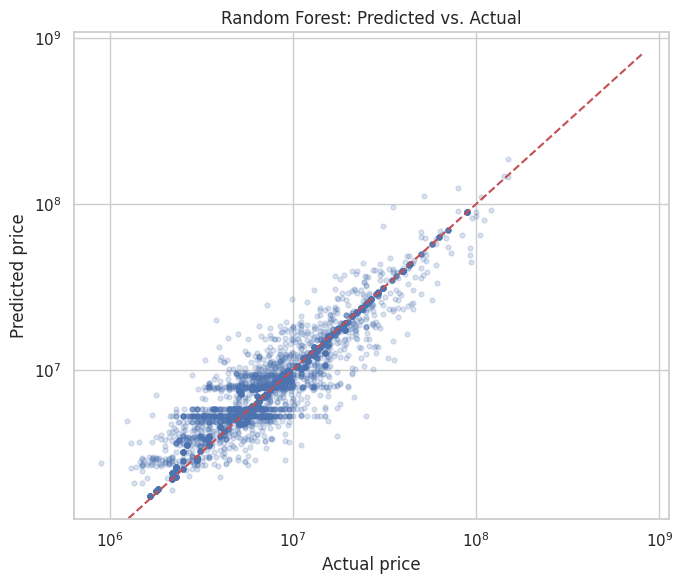

In [7]:
fig, ax = plt.subplots()
sample_idx = np.random.RandomState(42).choice(len(y_test), size=min(5000, len(y_test)), replace=False)
ax.scatter(y_test.values[sample_idx], final_pred[sample_idx], alpha=0.2, s=12)
lims = [0, max(y_test.max(), final_pred.max())]
ax.plot(lims, lims, "r--", linewidth=1.5)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Actual price")
ax.set_ylabel("Predicted price")
ax.set_title("Random Forest: Predicted vs. Actual")
plt.tight_layout()
plt.show()


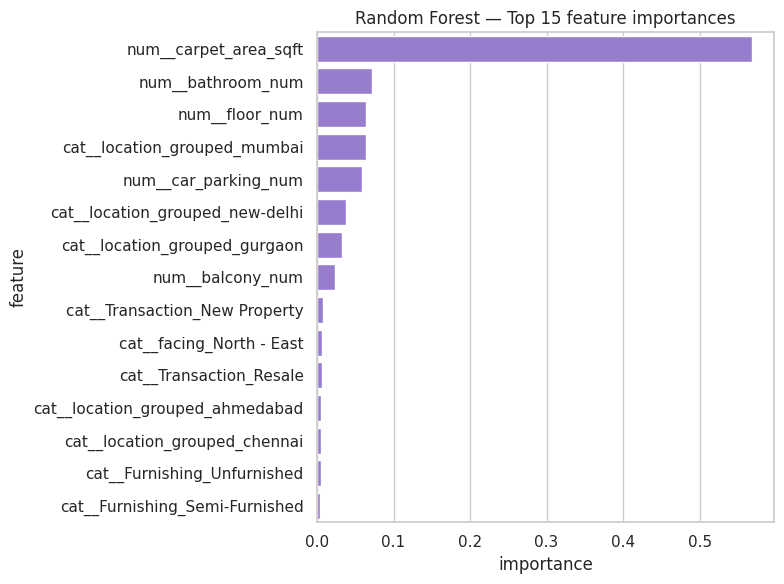

In [8]:
importances = model.named_steps["reg"].feature_importances_
feature_names = model.named_steps["prep"].get_feature_names_out()

imp_df = (pd.DataFrame({"feature": feature_names, "importance": importances})
          .sort_values("importance", ascending=False)
          .head(15))

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=imp_df, x="importance", y="feature", ax=ax, color="mediumpurple")
ax.set_title("Random Forest — Top 15 feature importances")
plt.tight_layout()
plt.show()


**Comment:** as expected from the EDA notebook, `carpet_area_sqft` and `bathroom_num` are
the most important predictors, followed by a number of specific `location_grouped` one-hot
categories — confirming that location is a major (and highly non-linear) driver of price that
Random Forest is able to exploit better than Linear Regression.


**Note on cross-validation:** running 5-fold CV with the full 60-tree model would be
very slow on a single CPU (it refits the model 5 times). For the CV check below we use a
lighter Random Forest (fewer trees / shallower depth) with the same preprocessing — this is
purely to keep runtime reasonable and still gives a reliable estimate of how stable the model
is across folds.


In [9]:
cv_model = Pipeline([
    ("prep", preprocessor),
    ("reg", RandomForestRegressor(n_estimators=20, max_depth=9, max_samples=0.4,
                                   n_jobs=-1, random_state=42)),
])

cv_scores = cross_val_score(
    cv_model, X, np.log1p(y) if use_log else y, cv=5, scoring="r2", n_jobs=1
)
print("5-fold CV R2 scores (lighter model):", np.round(cv_scores, 4))
print(f"Mean CV R2: {cv_scores.mean():.4f}  (+/- {cv_scores.std():.4f})")


5-fold CV R2 scores (lighter model): [0.561  0.5138 0.5647 0.4843 0.0278]
Mean CV R2: 0.4303  (+/- 0.2035)


**Summary paragraph:** Random Forest substantially improves on the Linear Regression
baseline (higher R², lower MAE/RMSE — see the comparison table in the README), because it can
model non-linear interactions between area, location, and amenities without any manual feature
engineering. The trade-off is a larger, slower-to-load model file and less interpretability
than a linear model.


## 5. Export the Model

In [10]:
import os
os.makedirs("../models", exist_ok=True)

joblib.dump(
    {"model": model, "use_log_target": use_log},
    "../models/random_forest.pkl"
)

# Sanity check: reload and predict one sample
loaded = joblib.load("../models/random_forest.pkl")
sample = X_test.iloc[[0]]
raw_pred = loaded["model"].predict(sample)
final_sample_pred = np.expm1(raw_pred) if loaded["use_log_target"] else raw_pred
print("Reloaded prediction:", final_sample_pred, " | Actual:", y_test.iloc[0])


Reloaded prediction: [6881999.91901542]  | Actual: 7000000.0


In [11]:
import sklearn
print("scikit-learn version used for training:", sklearn.__version__)


scikit-learn version used for training: 1.8.0
